# Thu thập dữ liệu giao dịch từ Bitget API

Notebook này sẽ lấy thông tin về 100 giao dịch gần nhất từ Bitget API với các thông tin như:
- ID giao dịch
- Giá
- Số lượng
- Hướng giao dịch (mua/bán)
- Thời gian
- Cặp giao dịch

In [7]:
# Import các thư viện cần thiết
import requests
import pandas as pd
import json
import time
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

## Cài đặt API Endpoint và tham số

Endpoint: `/api/v2/mix/market/fills`
- `symbol`: Cặp giao dịch (bắt buộc)
- `productType`: Loại sản phẩm (bắt buộc)
- `limit`: Số lượng kết quả muốn lấy (không bắt buộc, mặc định: 100)

In [8]:
# Cài đặt thông số API
base_url = "https://api.bitget.com"
endpoint = "/api/v2/mix/market/fills"
symbol = "BTCUSDT"  # Cặp giao dịch BTC/USDT
product_type = "usdt-futures"  # Loại sản phẩm: USDT futures
limit = 100  # Số lượng giao dịch muốn lấy (tối đa 100)

# Xây dựng URL với tham số
url = f"{base_url}{endpoint}?symbol={symbol}&productType={product_type}&limit={limit}"

print(f"URL yêu cầu: {url}")

URL yêu cầu: https://api.bitget.com/api/v2/mix/market/fills?symbol=BTCUSDT&productType=usdt-futures&limit=100


## Thực hiện yêu cầu API và xử lý kết quả

Chú ý: API có giới hạn tần suất 20 lần/1 giây cho mỗi IP

In [9]:
# Hàm để gửi yêu cầu API và xử lý lỗi
def get_recent_transactions(url):
    try:
        response = requests.get(url)
        response.raise_for_status()  # Kiểm tra lỗi HTTP
        return response.json()
    except requests.exceptions.HTTPError as e:
        print(f"Lỗi HTTP: {e}")
        return None
    except requests.exceptions.RequestException as e:
        print(f"Lỗi khi gửi yêu cầu: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"Lỗi khi phân tích JSON: {e}")
        return None

# Thực hiện yêu cầu API
result = get_recent_transactions(url)

# Kiểm tra kết quả
if result and result.get("code") == "00000":
    print("Yêu cầu thành công!")
    print(f"Số lượng giao dịch nhận được: {len(result.get('data', []))}")
else:
    print("Yêu cầu thất bại!")
    print(f"Mã lỗi: {result.get('code')}")
    print(f"Thông báo: {result.get('msg')}")

Yêu cầu thành công!
Số lượng giao dịch nhận được: 100


## Chuyển đổi dữ liệu sang DataFrame và xử lý

In [12]:
# Chuyển đổi dữ liệu thành DataFrame
if result and result.get("code") == "00000" and result.get("data"):
    df = pd.DataFrame(result["data"])
    
    # Chuyển đổi các cột số
    df["price"] = df["price"].astype(float)
    df["size"] = df["size"].astype(float)
    
    # Chuyển đổi timestamp sang định dạng datetime
    try:
        # Sửa lỗi: Không sử dụng astype(int) để tránh lỗi overflow
        df["datetime"] = pd.to_datetime(df["ts"], unit='ms')
    except Exception as e:
        print(f"Lỗi khi chuyển đổi timestamp: {e}")
        try:
            # Phương pháp thay thế
            df["datetime"] = pd.to_datetime(pd.to_numeric(df["ts"], errors='coerce'), unit='ms')
        except Exception as e2:
            print(f"Phương pháp thay thế cũng gặp lỗi: {e2}")
            # Nếu cả hai phương pháp đều thất bại, tạo cột datetime gần đúng
            from datetime import datetime
            print("Tạo cột datetime từ timestamp hiện tại")
            current_time = datetime.now()
            df["datetime"] = pd.date_range(
                end=current_time, 
                periods=len(df), 
                freq='S'
            )
    
    # Hiển thị 5 dòng đầu tiên của dữ liệu
    print(df.head())
    
    # Thông tin về DataFrame
    print("\nThông tin DataFrame:")
    print(df.info())
    
    # Thống kê mô tả
    print("\nThống kê mô tả:")
    print(df.describe())
else:
    print("Không có dữ liệu để xử lý.")

               tradeId     price    size  side             ts   symbol  \
0  1309377103883644929  110550.1  0.0046   buy  1747905749293  BTCUSDT   
1  1309377103682318336  110550.1  0.0079   buy  1747905749245  BTCUSDT   
2  1309377103338385410  110550.1  0.0279   buy  1747905749163  BTCUSDT   
3  1309377102872817668  110550.1  0.0148   buy  1747905749052  BTCUSDT   
4  1309377102780542979  110550.0  0.0044  sell  1747905749030  BTCUSDT   

                 datetime  
0 2025-05-22 09:22:29.293  
1 2025-05-22 09:22:29.245  
2 2025-05-22 09:22:29.163  
3 2025-05-22 09:22:29.052  
4 2025-05-22 09:22:29.030  

Thông tin DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   tradeId   100 non-null    object        
 1   price     100 non-null    float64       
 2   size      100 non-null    float64       
 3   side      100 non-null    o

C:\Users\daong\AppData\Local\Temp\ipykernel_8636\1670457134.py:12: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df["datetime"] = pd.to_datetime(df["ts"], unit='ms')


## Phân tích và Trực quan hóa dữ liệu

Tổng khối lượng theo hướng giao dịch:
   side     size
0   buy  11.5001
1  sell   5.6671


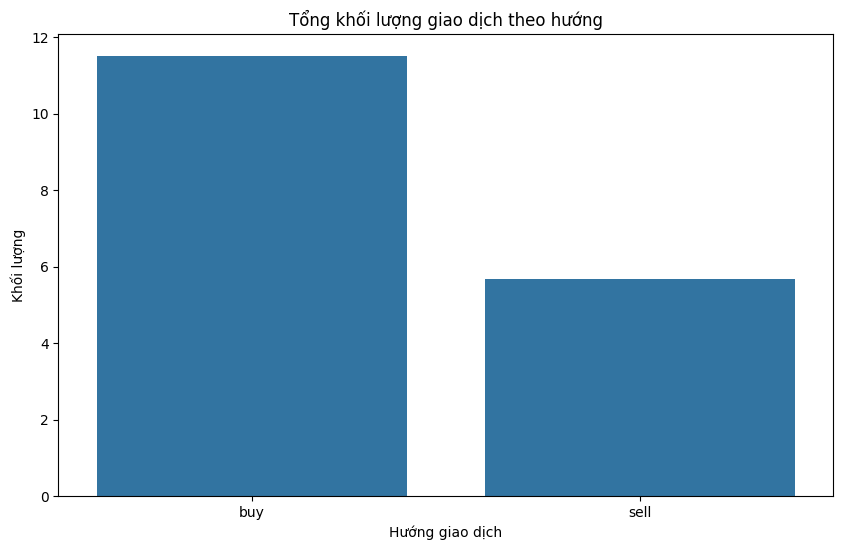

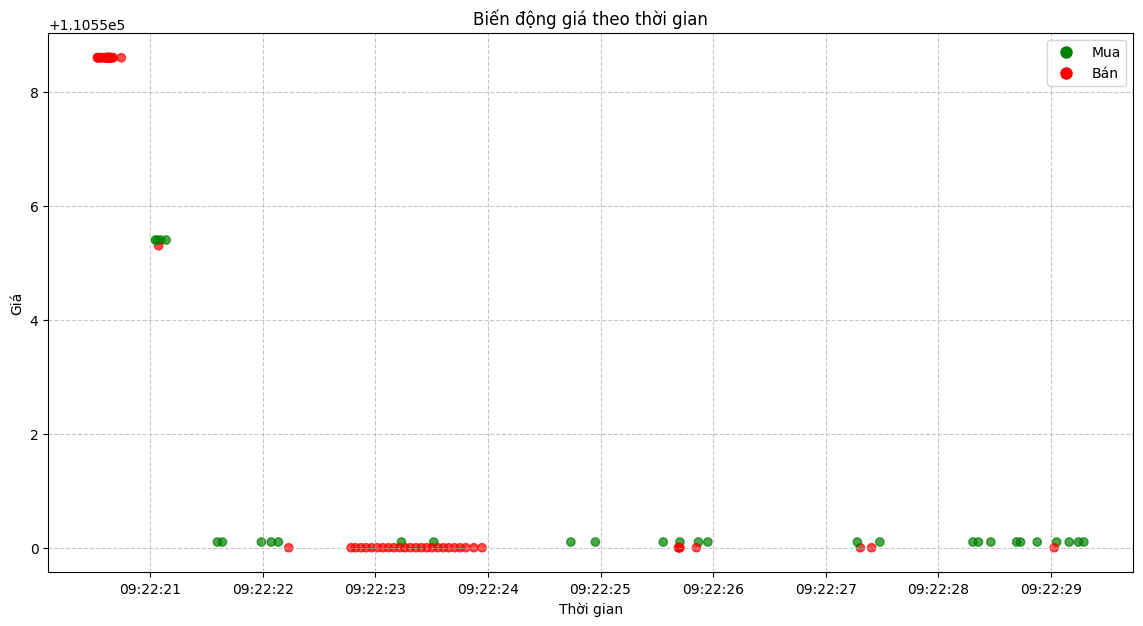

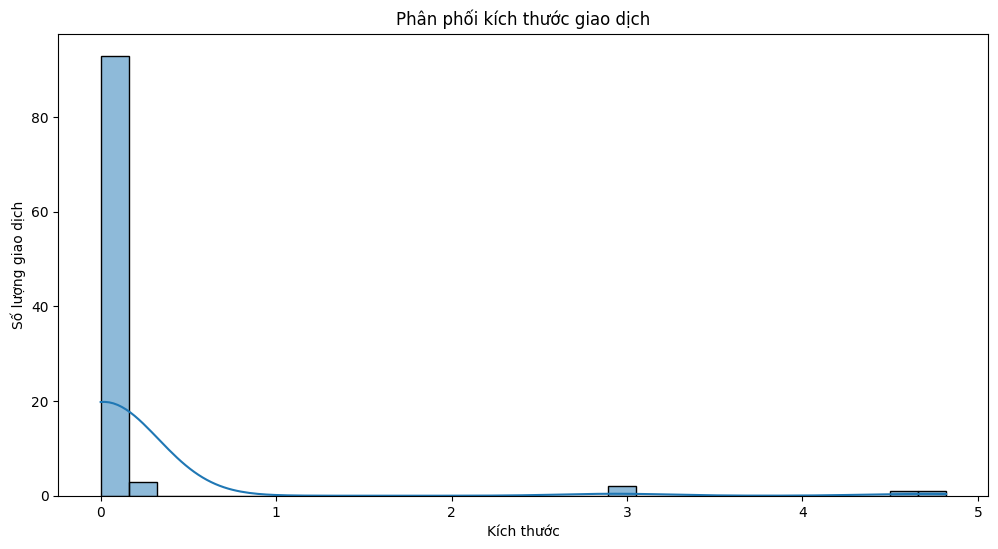

In [13]:
# Kiểm tra dữ liệu đã được lấy thành công
if 'df' in locals() and not df.empty:
    # 1. Tính tổng khối lượng giao dịch theo hướng (mua/bán)
    volume_by_side = df.groupby('side')['size'].sum().reset_index()
    print("Tổng khối lượng theo hướng giao dịch:")
    print(volume_by_side)
    
    # Biểu đồ khối lượng theo hướng giao dịch
    plt.figure(figsize=(10, 6))
    sns.barplot(x='side', y='size', data=volume_by_side)
    plt.title('Tổng khối lượng giao dịch theo hướng')
    plt.xlabel('Hướng giao dịch')
    plt.ylabel('Khối lượng')
    plt.show()
    
    # 2. Biểu đồ giá theo thời gian
    plt.figure(figsize=(14, 7))
    
    # Tạo color map cho mua/bán
    colors = {'buy': 'green', 'sell': 'red'}
    color_values = [colors.get(side, 'blue') for side in df['side']]
    
    # Vẽ biểu đồ với cột datetime nếu tồn tại, nếu không thì sử dụng index
    if 'datetime' in df.columns:
        plt.scatter(df['datetime'], df['price'], c=color_values, alpha=0.7)
        plt.xlabel('Thời gian')
    else:
        plt.scatter(range(len(df)), df['price'], c=color_values, alpha=0.7)
        plt.xlabel('Thứ tự giao dịch')
    
    plt.title('Biến động giá theo thời gian')
    plt.ylabel('Giá')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Tạo legend thủ công thay vì dùng colorbar
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor='green', markersize=10, label='Mua'),
                       Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor='red', markersize=10, label='Bán')]
    plt.legend(handles=legend_elements)
    
    plt.show()
    
    # 3. Phân phối kích thước giao dịch
    plt.figure(figsize=(12, 6))
    try:
        sns.histplot(df['size'], bins=30, kde=True)
    except Exception as e:
        print(f"Lỗi khi vẽ histplot: {e}")
        # Thử dùng matplotlib thay thế
        plt.hist(df['size'], bins=30)
    
    plt.title('Phân phối kích thước giao dịch')
    plt.xlabel('Kích thước')
    plt.ylabel('Số lượng giao dịch')
    plt.show()

## Lưu dữ liệu

Lưu dữ liệu vào các định dạng phổ biến để phân tích sau này

In [14]:
# Lưu dữ liệu vào các file với các định dạng khác nhau
if 'df' in locals() and not df.empty:
    # Tạo thư mục để lưu file nếu chưa tồn tại
    import os
    output_dir = "output_data"
    
    try:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        # Đặt tên file với timestamp để tránh ghi đè
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # Lưu dưới dạng CSV
        csv_filename = f"{output_dir}/bitget_transactions_{symbol}_{timestamp}.csv"
        df.to_csv(csv_filename, index=False)
        print(f"Đã lưu dữ liệu vào file CSV: {csv_filename}")
        
        # Lưu dưới dạng Excel
        try:
            excel_filename = f"{output_dir}/bitget_transactions_{symbol}_{timestamp}.xlsx"
            df.to_excel(excel_filename, index=False)
            print(f"Đã lưu dữ liệu vào file Excel: {excel_filename}")
        except Exception as e:
            print(f"Lỗi khi lưu file Excel: {e}")
            print("Cần cài đặt openpyxl: pip install openpyxl")
        
        # Lưu dưới dạng JSON
        json_filename = f"{output_dir}/bitget_transactions_{symbol}_{timestamp}.json"
        df.to_json(json_filename, orient="records")
        print(f"Đã lưu dữ liệu vào file JSON: {json_filename}")
    except Exception as e:
        print(f"Lỗi khi lưu file: {e}")
else:
    print("Không có dữ liệu để lưu.")

Đã lưu dữ liệu vào file CSV: output_data/bitget_transactions_BTCUSDT_20250522_162525.csv
Đã lưu dữ liệu vào file Excel: output_data/bitget_transactions_BTCUSDT_20250522_162525.xlsx
Đã lưu dữ liệu vào file JSON: output_data/bitget_transactions_BTCUSDT_20250522_162525.json


## Kết luận

Notebook này đã thực hiện các công việc sau:

1. Kết nối với Bitget API để lấy 100 giao dịch gần nhất của cặp {symbol}
2. Phân tích dữ liệu cơ bản và hiển thị thông tin thống kê
3. Trực quan hóa dữ liệu với các biểu đồ
4. Lưu dữ liệu vào các định dạng phổ biến để phân tích sau này

Lưu ý: Để lấy dữ liệu cho cặp giao dịch khác, chỉ cần thay đổi biến `symbol` trong notebook.